In [1]:
from google.colab import drive
drive.mount("/content/drive")

ValueError: Mountpoint must not already contain files

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

In [9]:
ROSTAT_DIR = Path("/content/drive/MyDrive/rostat")

SALES_FILE = ROSTAT_DIR / "[2017-2025]_sales_dynamics.xls"

PRICE_PROCESSED_DIR = ROSTAT_DIR / "processed"
SALES_OUT_DIR = ROSTAT_DIR / "processed_sales"
SALES_OUT_DIR.mkdir(parents=True, exist_ok=True)

PRODUCT_DICT_FILE = PRICE_PROCESSED_DIR / "product_dictionary.csv"
PRODUCT_GROUPS_FILE = PRICE_PROCESSED_DIR / "product_groups.csv"

OUT_SALES_LONG = SALES_OUT_DIR / "sales_dynamics_long.csv"
OUT_SALES_WIDE = SALES_OUT_DIR / "sales_dynamics_wide.csv"
OUT_SALES_ANNUAL = SALES_OUT_DIR / "sales_dynamics_annual.csv"
OUT_SALES_MAPPING = SALES_OUT_DIR / "sales_to_price_mapping.csv"

if not SALES_FILE.exists():
    raise FileNotFoundError(f"Не найден файл продаж: {SALES_FILE}")

if not PRODUCT_DICT_FILE.exists():
    raise FileNotFoundError(f"Не найден справочник товаров: {PRODUCT_DICT_FILE}")

if not PRODUCT_GROUPS_FILE.exists():
    raise FileNotFoundError(f"Не найден справочник категорий: {PRODUCT_GROUPS_FILE}")

price_products = pd.read_csv(PRODUCT_DICT_FILE)
product_groups = pd.read_csv(PRODUCT_GROUPS_FILE)

display(price_products.head())
display(product_groups)

,product_code,product_key,product_name,unit,product_group_code,product_group_name,product_raw
0,P0005,баранина_кроме_бескостного_мяса__кг,Баранина (кроме бескостного мяса),кг,G03,"Мясо, птица, рыба и колбасные изделия","Баранина (кроме бескостного мяса), кг"
1,P0006,бензин_автомобильный,Бензин автомобильный,NaN,G10,Топливо и транспортные товары,Бензин автомобильный
2,P0008,бензин_автомобильный_марки_аи_92__л,Бензин автомобильный марки АИ-92,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-92, л"
3,P0009,бензин_автомобильный_марки_аи_95__л,Бензин автомобильный марки АИ-95,л,G10,Топливо и транспортные товары,"Бензин автомобильный марки АИ-95, л"
4,P0017,вермишель__кг,Вермишель,кг,G01,"Хлеб, крупы, мука и макаронные изделия","Вермишель, кг"


,product_group_code,product_group_name
0,G01,"Хлеб, крупы, мука и макаронные изделия"
1,G02,Молочная продукция и яйца
2,G03,"Мясо, птица, рыба и колбасные изделия"
3,G04,"Овощи, фрукты и картофель"
4,G05,"Бакалея, масло, сахар, чай, соль"
5,G07,"Товары для дома, гигиены и бытовая химия"
6,G10,Топливо и транспортные товары
7,G11,Услуги
8,G99,Прочее


In [10]:
def clean_text(value):
    if pd.isna(value):
        return None
    
    text = str(value).strip()
    text = text.replace("\n", " ")
    text = text.replace("\xa0", " ")
    text = re.sub(r"\s+", " ", text)
    
    if text == "":
        return None
    
    return text


def clean_number(value):
    if pd.isna(value):
        return np.nan
    
    if isinstance(value, str):
        value = value.replace("\xa0", "")
        value = value.replace(" ", "")
        value = value.replace(",", ".")
        value = value.replace("−", "-")
    
    return pd.to_numeric(value, errors="coerce")


def normalize_key(text):
    text = clean_text(text)
    
    if text is None:
        return None
    
    key = text.lower()
    key = key.replace("ё", "е")
    key = re.sub(r"[^а-яa-z0-9]+", "_", key)
    key = re.sub(r"_+", "_", key).strip("_")
    
    return key


def clean_sales_product_name(product_raw):
    text = clean_text(product_raw)
    
    if text is None:
        return None
    
    text = re.sub(
        r"^Услуги по розничной торговле\s+",
        "",
        text,
        flags=re.IGNORECASE
    )
    
    text = re.sub(
        r"\s+в специализированных магазинах$",
        "",
        text,
        flags=re.IGNORECASE
    )
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


def period_to_quarter(period_label):
    period_label = clean_text(period_label)
    
    mapping = {
        "январь-март": 1,
        "январь-июнь": 2,
        "январь-сентябрь": 3,
        "январь-декабрь": 4
    }
    
    return mapping.get(period_label)


def quarter_end_date(year, quarter):
    month_map = {
        1: 3,
        2: 6,
        3: 9,
        4: 12
    }
    
    month = month_map[quarter]
    return pd.Timestamp(year=int(year), month=month, day=1) + pd.offsets.MonthEnd(0)

In [11]:
def assign_existing_product_group(sales_product_name):
    """
    Возвращает product_group_code из уже существующего product_groups.csv.
    Новые категории не создаются.
    """
    
    text = clean_text(sales_product_name)
    
    if text is None:
        return "G99"
    
    text = text.lower().replace("ё", "е")
    
    # Итого лучше не смешивать с товарными категориями
    if "всего по розничной торговле" in text:
        return None
    
    if re.search(r"хлеб|хлебобулоч|круп|макарон|мука", text):
        return "G01"
    
    if re.search(r"молок|молоч|сыр|яйц", text):
        return "G02"
    
    if re.search(r"мяс|птиц|рыб|морепродукт|ракообраз|моллюск", text):
        return "G03"
    
    if re.search(r"картоф|овощ|фрукт", text):
        return "G04"
    
    if re.search(r"сахар|соль|чай|кофе|какао|масл|жир|маргарин|кондитер|напит|вод", text):
        return "G05"
    
    if re.search(r"лекар|медицин|ортопед|космет|парфюмер|мыл", text):
        # В существующем справочнике цен лекарства и гигиена могут быть разделены,
        # но в продажах Росстата они часто идут агрегированно.
        # Если G08 есть в product_groups.csv, используем G08.
        # Если G08 нет, отправляем в G99.
        return "G08" if "G08" in set(product_groups["product_group_code"]) else "G99"
    
    if re.search(r"одежд|мех|чулочно|носоч|обув|бель|текстил", text):
        return "G09" if "G09" in set(product_groups["product_group_code"]) else "G99"
    
    if re.search(r"автомоб|мотоцикл|бензин|дизель|топлив|газ|деталями|узлами|принадлежностями", text):
        return "G10" if "G10" in set(product_groups["product_group_code"]) else "G99"
    
    if re.search(r"мебел|строительн|бытов|дом|ремонт", text):
        return "G07" if "G07" in set(product_groups["product_group_code"]) else "G99"
    
    return "G99"

In [12]:
from difflib import SequenceMatcher

price_products_match = price_products.copy()
price_products_match["product_name_norm"] = price_products_match["product_name"].apply(normalize_key)


def find_best_price_product_match(sales_product_name, product_group_code, min_score=0.35):
    """
    Пытается найти близкий товар из product_dictionary.csv внутри той же категории.
    Возвращает product_code, product_name и similarity_score.
    Если совпадение слабое — возвращает None.
    """
    
    if product_group_code is None:
        return None, None, np.nan
    
    candidates = price_products_match[
        price_products_match["product_group_code"] == product_group_code
    ].copy()
    
    if candidates.empty:
        return None, None, np.nan
    
    sales_norm = normalize_key(sales_product_name)
    
    if sales_norm is None:
        return None, None, np.nan
    
    best_score = -1
    best_code = None
    best_name = None
    
    for _, row in candidates.iterrows():
        candidate_norm = row["product_name_norm"]
        
        if pd.isna(candidate_norm):
            continue
        
        score = SequenceMatcher(None, sales_norm, candidate_norm).ratio()
        
        if score > best_score:
            best_score = score
            best_code = row["product_code"]
            best_name = row["product_name"]
    
    if best_score < min_score:
        return None, None, best_score
    
    return best_code, best_name, best_score

In [47]:
def is_russian_federation_region(region):
    text = clean_text(region)
    
    if text is None:
        return False
    
    text = text.lower().replace("ё", "е")
    
    return text.startswith("российская федерация")

In [48]:
def process_sales_dynamics_file_with_existing_dict(file_path):
    raw = pd.read_excel(
        file_path,
        sheet_name="Данные",
        header=None,
        engine="xlrd"
    )
    
    print("Размер листа Данные:", raw.shape)
    display(raw.head(6))
    
    year_row_idx = 2
    period_row_idx = 3
    data_start_row = 4
    
    region_col = 0
    product_col = 1
    
    columns_meta = []
    current_year = None
    
    for col_idx in range(2, raw.shape[1]):
        year_value = clean_text(raw.iloc[year_row_idx, col_idx])
        period_value = clean_text(raw.iloc[period_row_idx, col_idx])
        
        if year_value is not None:
            try:
                current_year = int(float(year_value))
            except Exception:
                pass
        
        quarter = period_to_quarter(period_value)
        
        if current_year is not None and quarter is not None:
            columns_meta.append({
                "col_idx": col_idx,
                "year": current_year,
                "quarter": quarter,
                "period_label": period_value,
                "period_end": quarter_end_date(current_year, quarter)
            })
    
    columns_meta = pd.DataFrame(columns_meta)
    
    print("Распознанные периоды:")
    display(columns_meta)
    
    data = raw.iloc[data_start_row:].copy()
    
    records = []
    
    for _, row in data.iterrows():
        region_raw = clean_text(row.get(region_col))
        product_raw = clean_text(row.get(product_col))
        
        # Главное исправление:
        # теперь оставляем и "Российская Федерация",
        # и "Российская Федерация без учета новых субъектов (с 01.01.2023)"
        if not is_russian_federation_region(region_raw):
            continue
        
        region = "Российская Федерация"
        region_original = region_raw
        
        if product_raw is None:
            continue
        
        product_name = clean_sales_product_name(product_raw)
        sales_product_key = normalize_key(product_name)
        
        product_group_code = assign_existing_product_group(product_name)
        
        # Исключаем итоговую строку, если она не относится к категории
        if product_group_code is None:
            continue
        
        for _, meta in columns_meta.iterrows():
            value = clean_number(row.get(meta["col_idx"]))
            
            if pd.notna(value):
                records.append({
                    "region": region,
                    "region_original": region_original,
                    "period_end": meta["period_end"],
                    "year": int(meta["year"]),
                    "quarter": int(meta["quarter"]),
                    "period_label": meta["period_label"],
                    "sales_product_raw": product_raw,
                    "sales_product_name": product_name,
                    "sales_product_key": sales_product_key,
                    "product_group_code": product_group_code,
                    "sales_cumulative_thousand_rub": float(value),
                    "source_file": file_path.name,
                    "source_sheet": "Данные"
                })
    
    sales_raw = pd.DataFrame(records)
    
    sales_raw = sales_raw.merge(
        product_groups[["product_group_code", "product_group_name"]],
        on="product_group_code",
        how="left"
    )
    
    sales_raw = sales_raw.sort_values(
        ["sales_product_key", "year", "quarter"]
    ).reset_index(drop=True)
    
    print("После обработки sales_dynamics:")
    print("Строк:", len(sales_raw))
    print("Позиций продаж:", sales_raw["sales_product_key"].nunique())
    print("Категорий:", sales_raw["product_group_code"].nunique())
    print("Период:", sales_raw["period_end"].min(), "—", sales_raw["period_end"].max())
    
    print("\nКакие исходные подписи территории попали в данные:")
    display(
        sales_raw[["year", "region_original"]]
        .drop_duplicates()
        .sort_values(["year", "region_original"])
    )
    
    return sales_raw


sales_raw = process_sales_dynamics_file_with_existing_dict(SALES_FILE)

Размер листа Данные: (160, 38)


,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,Розничная продажа основных товаров c 2017 г. (...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,2017,NaN,NaN,NaN,2018,NaN,NaN,NaN,...,NaN,NaN,2024,NaN,NaN,NaN,2025,NaN,NaN,NaN
3,NaN,NaN,январь-март,январь-июнь,январь-сентябрь,январь-декабрь,январь-март,январь-июнь,январь-сентябрь,январь-декабрь,...,январь-сентябрь,январь-декабрь,январь-март,январь-июнь,январь-сентябрь,январь-декабрь,январь-март,январь-июнь,январь-сентябрь,январь-декабрь
4,Российская Федерация,Услуги по розничной торговле автомобильными де...,53147411.75,106665477.2,175831374.5,250892348,55594933.8,108762344,169846304.2,246364646.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Российская Федерация,Услуги по розничной торговле консервами из рыб...,32302574.3,64333109.4,96239551.8,135533261.2,32907263.3,65769740.1,98199545.6,139002964.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Распознанные периоды:


,col_idx,year,quarter,period_label,period_end
0,2,2017,1,январь-март,2017-03-31
1,3,2017,2,январь-июнь,2017-06-30
2,4,2017,3,январь-сентябрь,2017-09-30
3,5,2017,4,январь-декабрь,2017-12-31
4,6,2018,1,январь-март,2018-03-31
5,7,2018,2,январь-июнь,2018-06-30
6,8,2018,3,январь-сентябрь,2018-09-30
7,9,2018,4,январь-декабрь,2018-12-31
8,10,2019,1,январь-март,2019-03-31
9,11,2019,2,январь-июнь,2019-06-30


После обработки sales_dynamics:
Строк: 2638
Позиций продаж: 80
Категорий: 8
Период: 2017-03-31 00:00:00 — 2025-12-31 00:00:00

Какие исходные подписи территории попали в данные:


,year,region_original
0,2017,Российская Федерация
4,2018,Российская Федерация
8,2019,Российская Федерация
12,2020,Российская Федерация
16,2021,Российская Федерация
20,2022,Российская Федерация
24,2023,Российская Федерация без учета новых субъектов...
28,2024,Российская Федерация без учета новых субъектов...
32,2025,Российская Федерация без учета новых субъектов...


In [49]:
sales_mapping = (
    sales_raw[
        [
            "sales_product_key",
            "sales_product_name",
            "sales_product_raw",
            "product_group_code",
            "product_group_name"
        ]
    ]
    .drop_duplicates()
    .sort_values(["product_group_code", "sales_product_name"])
    .reset_index(drop=True)
)

matches = []

for _, row in sales_mapping.iterrows():
    matched_code, matched_name, score = find_best_price_product_match(
        sales_product_name=row["sales_product_name"],
        product_group_code=row["product_group_code"],
        min_score=0.35
    )
    
    matches.append({
        "matched_price_product_code": matched_code,
        "matched_price_product_name": matched_name,
        "match_score": score
    })

matches = pd.DataFrame(matches)

sales_mapping = pd.concat([sales_mapping, matches], axis=1)

sales_mapping["sales_product_code"] = [
    f"R{str(i + 1).zfill(4)}"
    for i in range(len(sales_mapping))
]

sales_mapping = sales_mapping[
    [
        "sales_product_code",
        "sales_product_key",
        "sales_product_name",
        "product_group_code",
        "product_group_name",
        "matched_price_product_code",
        "matched_price_product_name",
        "match_score",
        "sales_product_raw"
    ]
]

display(sales_mapping)

,sales_product_code,sales_product_key,sales_product_name,product_group_code,product_group_name,matched_price_product_code,matched_price_product_name,match_score,sales_product_raw
0,R0001,макаронные_изделия,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",P0059,Макаронные изделия из пшеничной муки высшего с...,0.529412,Макаронные изделия
1,R0002,мука,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",P0072,Мука пшеничная,0.444444,Мука
2,R0003,крупами,крупами,G01,"Хлеб, крупы, мука и макаронные изделия",P0049,Крупа гречневая-ядрица,0.413793,Услуги по розничной торговле крупами в специал...
3,R0004,хлебом_и_хлебобулочными_изделиями,хлебом и хлебобулочными изделиями,G01,"Хлеб, крупы, мука и макаронные изделия",P0152,Хлеб из ржаной муки и из смеси муки ржаной и п...,0.390805,Услуги по розничной торговле хлебом и хлебобул...
4,R0005,консервы_молочные_молочные_составные_сухие_суб...,"Консервы молочные, молочные составные сухие, с...",G02,Молочная продукция и яйца,None,None,0.333333,"Консервы молочные, молочные составные сухие, с..."
...,...,...,...,...,...,...,...,...,...
75,R0076,табачными_изделиями,табачными изделиями,G99,Прочее,None,None,0.341463,Услуги по розничной торговле табачными изделия...
76,R0077,туалетным_и_хозяйственным_мылом,туалетным и хозяйственным мылом,G99,Прочее,None,None,0.339623,Услуги по розничной торговле туалетным и хозяй...
77,R0078,часами,часами,G99,Прочее,None,None,0.333333,Услуги по розничной торговле часами в специали...
78,R0079,чулочно_носочными_изделиями,чулочно-носочными изделиями,G99,Прочее,None,None,0.300000,Услуги по розничной торговле чулочно-носочными...


In [50]:
sales_long = sales_raw.merge(
    sales_mapping[
        [
            "sales_product_code",
            "sales_product_key",
            "matched_price_product_code",
            "matched_price_product_name"
        ]
    ],
    on="sales_product_key",
    how="left"
)

sales_long = sales_long.sort_values(
    ["sales_product_code", "year", "quarter"]
).reset_index(drop=True)

sales_long["sales_quarter_thousand_rub"] = (
    sales_long
    .groupby(["sales_product_code", "year"])["sales_cumulative_thousand_rub"]
    .diff()
)

q1_mask = sales_long["quarter"] == 1

sales_long.loc[q1_mask, "sales_quarter_thousand_rub"] = (
    sales_long.loc[q1_mask, "sales_cumulative_thousand_rub"]
)

sales_long["sales_quarter_thousand_rub"] = (
    sales_long["sales_quarter_thousand_rub"].round(3)
)

sales_long = sales_long[
    [
        "period_end",
        "year",
        "quarter",
        "period_label",
        "sales_product_code",
        "sales_product_name",
        "product_group_code",
        "product_group_name",
        "matched_price_product_code",
        "sales_cumulative_thousand_rub",
        "sales_quarter_thousand_rub",
        "source_file",
        "source_sheet"
    ]
].sort_values(["period_end", "sales_product_code"]).reset_index(drop=True)

display(sales_long.head())

,period_end,year,quarter,period_label,sales_product_code,sales_product_name,product_group_code,product_group_name,matched_price_product_code,sales_cumulative_thousand_rub,sales_quarter_thousand_rub,source_file,source_sheet
0,2017-03-31,2017,1,январь-март,R0001,Макаронные изделия,G01,"Хлеб, крупы, мука и макаронные изделия",P0059,3.731784e+07,3.731784e+07,[2017-2025]_sales_dynamics.xls,Данные
1,2017-03-31,2017,1,январь-март,R0002,Мука,G01,"Хлеб, крупы, мука и макаронные изделия",P0072,2.608453e+07,2.608453e+07,[2017-2025]_sales_dynamics.xls,Данные
2,2017-03-31,2017,1,январь-март,R0003,крупами,G01,"Хлеб, крупы, мука и макаронные изделия",P0049,4.671274e+07,4.671274e+07,[2017-2025]_sales_dynamics.xls,Данные
3,2017-03-31,2017,1,январь-март,R0004,хлебом и хлебобулочными изделиями,G01,"Хлеб, крупы, мука и макаронные изделия",P0152,1.516048e+08,1.516048e+08,[2017-2025]_sales_dynamics.xls,Данные
4,2017-03-31,2017,1,январь-март,R0005,"Консервы молочные, молочные составные сухие, с...",G02,Молочная продукция и яйца,None,9.729266e+06,9.729266e+06,[2017-2025]_sales_dynamics.xls,Данные


In [51]:
sales_group_long = (
    sales_long
    .groupby(
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name"
        ],
        as_index=False
    )
    .agg(
        sales_quarter_thousand_rub=("sales_quarter_thousand_rub", "sum"),
        sales_cumulative_thousand_rub=("sales_cumulative_thousand_rub", "sum"),
        n_sales_products=("sales_product_code", "nunique")
    )
    .sort_values(["period_end", "product_group_code"])
)

display(sales_group_long.head())

,period_end,year,quarter,product_group_code,product_group_name,sales_quarter_thousand_rub,sales_cumulative_thousand_rub,n_sales_products
0,2017-03-31,2017,1,G01,"Хлеб, крупы, мука и макаронные изделия",2.617199e+08,2.617199e+08,4
1,2017-03-31,2017,1,G02,Молочная продукция и яйца,5.576064e+08,5.576064e+08,6
2,2017-03-31,2017,1,G03,"Мясо, птица, рыба и колбасные изделия",1.298886e+09,1.298886e+09,7
3,2017-03-31,2017,1,G04,"Овощи, фрукты и картофель",2.454972e+08,2.454972e+08,3
4,2017-03-31,2017,1,G05,"Бакалея, масло, сахар, чай, соль",7.311585e+08,7.311585e+08,10


In [52]:
sales_group_wide = (
    sales_group_long
    .pivot_table(
        index="period_end",
        columns="product_group_code",
        values="sales_quarter_thousand_rub",
        aggfunc="sum"
    )
    .reset_index()
)

sales_group_wide.columns.name = None

display(sales_group_wide.head())

,period_end,G01,G02,G03,G04,G05,G07,G10,G99
0,2017-03-31,2.617199e+08,5.576064e+08,1.298886e+09,2.454972e+08,7.311585e+08,1.944293e+08,9.297147e+08,1.765803e+09
1,2017-06-30,2.578767e+08,5.391947e+08,1.301618e+09,2.805652e+08,7.621639e+08,2.314105e+08,1.046681e+09,1.833087e+09
2,2017-09-30,3.008927e+08,6.113359e+08,1.422275e+09,3.098659e+08,8.214402e+08,2.648436e+08,1.199522e+09,1.998716e+09
3,2017-12-31,3.555661e+08,6.618822e+08,1.555811e+09,3.446359e+08,9.662895e+08,3.056368e+08,1.346352e+09,2.362237e+09
4,2018-03-31,2.671137e+08,5.844667e+08,1.326182e+09,2.662916e+08,7.529142e+08,2.081310e+08,1.061934e+09,1.906130e+09


In [53]:
sales_long.to_csv(
    SALES_OUT_DIR / "sales_dynamics_long.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_group_long.to_csv(
    SALES_OUT_DIR / "sales_dynamics_by_existing_categories.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_group_wide.to_csv(
    SALES_OUT_DIR / "sales_dynamics_by_existing_categories_wide.csv",
    index=False,
    encoding="utf-8-sig"
)

sales_mapping.to_csv(
    OUT_SALES_MAPPING,
    index=False,
    encoding="utf-8-sig"
)

print("Файлы сохранены:")
print(SALES_OUT_DIR / "sales_dynamics_long.csv")
print(SALES_OUT_DIR / "sales_dynamics_by_existing_categories.csv")
print(SALES_OUT_DIR / "sales_dynamics_by_existing_categories_wide.csv")
print(OUT_SALES_MAPPING)

Файлы сохранены:
/content/drive/MyDrive/rostat/processed_sales/sales_dynamics_long.csv
/content/drive/MyDrive/rostat/processed_sales/sales_dynamics_by_existing_categories.csv
/content/drive/MyDrive/rostat/processed_sales/sales_dynamics_by_existing_categories_wide.csv
/content/drive/MyDrive/rostat/processed_sales/sales_to_price_mapping.csv


In [54]:
print("Проверка обработанных продаж")

print("\nsales_long:")
print(sales_long.shape)
print("Период:", sales_long["period_end"].min(), "—", sales_long["period_end"].max())
print("Позиции продаж:", sales_long["sales_product_code"].nunique())
print("Категории:", sales_long["product_group_code"].nunique())

print("\nРаспределение позиций продаж по существующим категориям:")
display(
    sales_mapping
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(
        sales_products=("sales_product_code", "nunique"),
        matched_price_products=("matched_price_product_code", "nunique")
    )
    .sort_values("product_group_code")
)

print("\nПроверка квартальных продаж по годам:")
display(
    sales_long
    .groupby("year", as_index=False)
    .agg(
        rows=("sales_quarter_thousand_rub", "size"),
        quarters=("quarter", "nunique"),
        sales_products=("sales_product_code", "nunique"),
        total_sales=("sales_quarter_thousand_rub", "sum")
    )
)

print("\nОтрицательные квартальные продажи:")
negative_sales = sales_long[
    sales_long["sales_quarter_thousand_rub"] < 0
]

print(len(negative_sales))
display(negative_sales.head(20))

Проверка обработанных продаж

sales_long:
(2638, 13)
Период: 2017-03-31 00:00:00 — 2025-12-31 00:00:00
Позиции продаж: 80
Категории: 8

Распределение позиций продаж по существующим категориям:


,product_group_code,product_group_name,sales_products,matched_price_products
0,G01,"Хлеб, крупы, мука и макаронные изделия",4,4
1,G02,Молочная продукция и яйца,6,2
2,G03,"Мясо, птица, рыба и колбасные изделия",7,1
3,G04,"Овощи, фрукты и картофель",4,2
4,G05,"Бакалея, масло, сахар, чай, соль",11,3
5,G07,"Товары для дома, гигиены и бытовая химия",5,1
6,G10,Топливо и транспортные товары,10,4
7,G99,Прочее,33,5



Проверка квартальных продаж по годам:


,year,rows,quarters,sales_products,total_sales
0,2017,304,4,76,2.706471e+10
1,2018,304,4,76,2.890049e+10
2,2019,300,4,75,3.065139e+10
3,2020,300,4,75,3.157783e+10
4,2021,300,4,75,3.730932e+10
5,2022,289,4,73,3.608638e+10
6,2023,276,4,69,3.874575e+10
7,2024,293,4,77,4.575878e+10
8,2025,272,4,68,4.829678e+10



Отрицательные квартальные продажи:
1


,period_end,year,quarter,period_label,sales_product_code,sales_product_name,product_group_code,product_group_name,matched_price_product_code,sales_cumulative_thousand_rub,sales_quarter_thousand_rub,source_file,source_sheet
113,2017-06-30,2017,2,январь-июнь,R0042,Компримированный природный газ,G10,Топливо и транспортные товары,P0054,1169105.8,-120319.2,[2017-2025]_sales_dynamics.xls,Данные


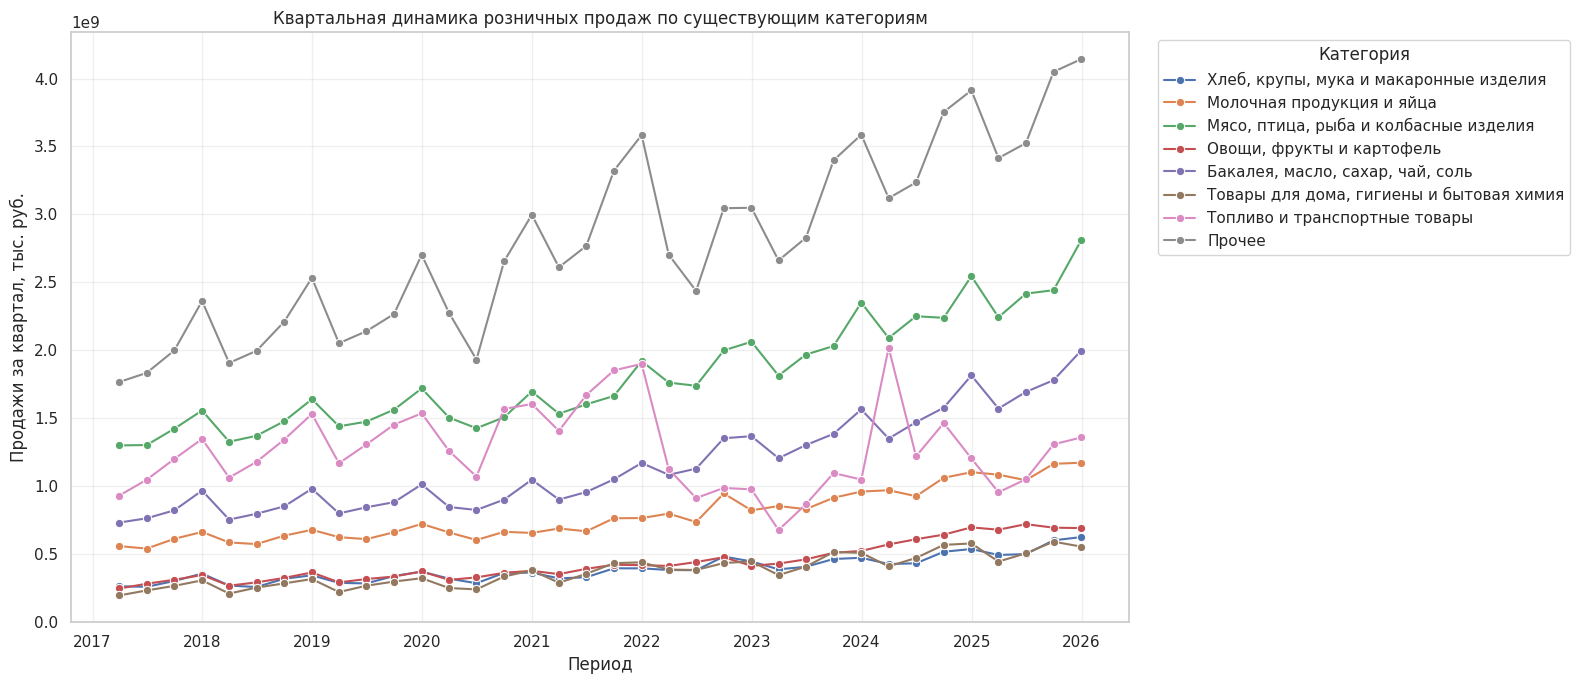

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(16, 7))

sns.lineplot(
    data=sales_group_long,
    x="period_end",
    y="sales_quarter_thousand_rub",
    hue="product_group_name",
    marker="o"
)

plt.title("Квартальная динамика розничных продаж по существующим категориям")
plt.xlabel("Период")
plt.ylabel("Продажи за квартал, тыс. руб.")
plt.legend(title="Категория", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [56]:
sns.set_theme(style="whitegrid")

BASE_DIR = Path("/content/drive/MyDrive/rostat")

PRICE_DIR = BASE_DIR / "processed"
SALES_DIR = BASE_DIR / "processed_sales"

prices_long = pd.read_csv(
    PRICE_DIR / "weekly_prices_long.csv",
    parse_dates=["date"]
)

products = pd.read_csv(
    PRICE_DIR / "product_dictionary.csv"
)

product_groups = pd.read_csv(
    PRICE_DIR / "product_groups.csv"
)

sales_group_long = pd.read_csv(
    SALES_DIR / "sales_dynamics_by_existing_categories.csv",
    parse_dates=["period_end"]
)

sales_long = pd.read_csv(
    SALES_DIR / "sales_dynamics_long.csv",
    parse_dates=["period_end"]
)

sales_mapping = pd.read_csv(
    SALES_DIR / "sales_to_price_mapping.csv"
)

prices_plot = prices_long.merge(
    products[
        [
            "product_code",
            "product_name",
            "product_group_code",
            "product_group_name"
        ]
    ],
    on="product_code",
    how="left"
)

prices_plot["year"] = prices_plot["date"].dt.year
prices_plot["quarter"] = prices_plot["date"].dt.quarter

# Для сопоставимых графиков исключим неполный 2026 год
prices_plot = prices_plot[prices_plot["year"] <= 2025].copy()
sales_group_long = sales_group_long[sales_group_long["year"] <= 2025].copy()
sales_long = sales_long[sales_long["year"] <= 2025].copy()

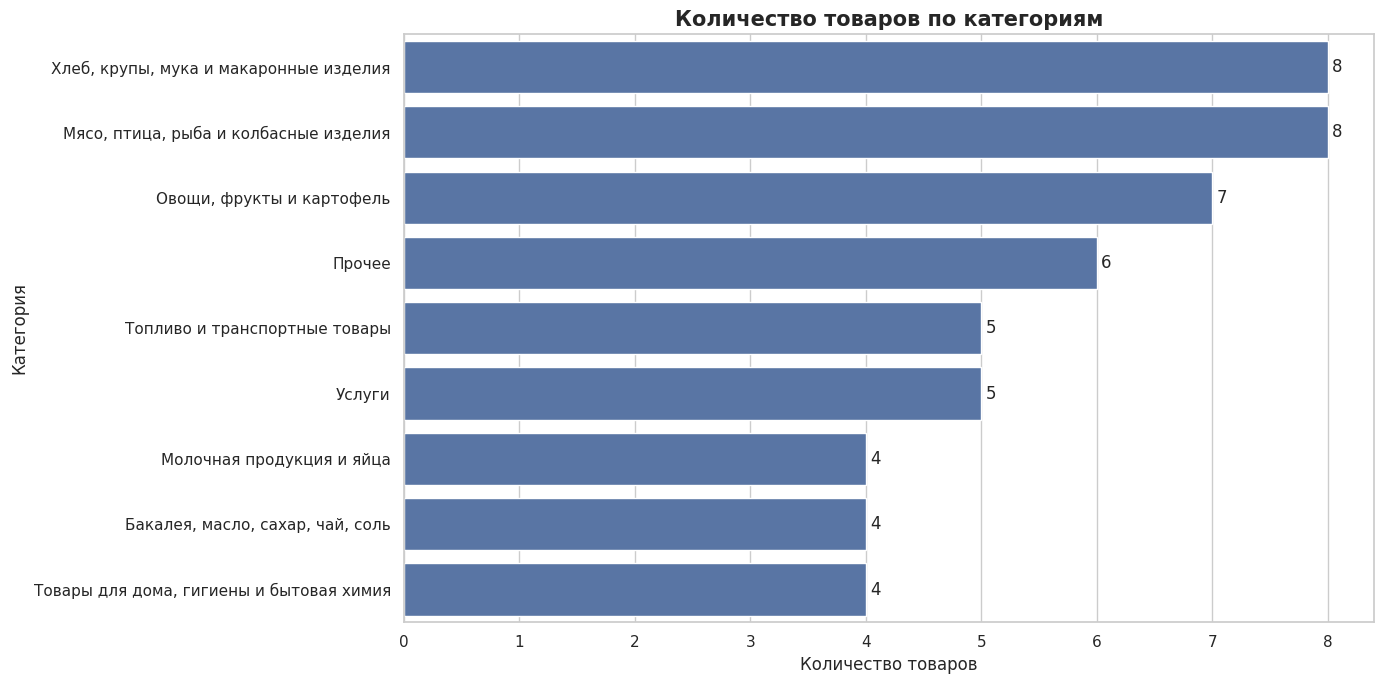

In [57]:
category_counts = (
    products
    .groupby(["product_group_code", "product_group_name"], as_index=False)
    .agg(products_count=("product_code", "nunique"))
    .sort_values("products_count", ascending=False)
)

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=category_counts,
    x="products_count",
    y="product_group_name"
)

plt.title("Количество товаров по категориям", fontsize=15, fontweight="bold")
plt.xlabel("Количество товаров")
plt.ylabel("Категория")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.tight_layout()
plt.show()

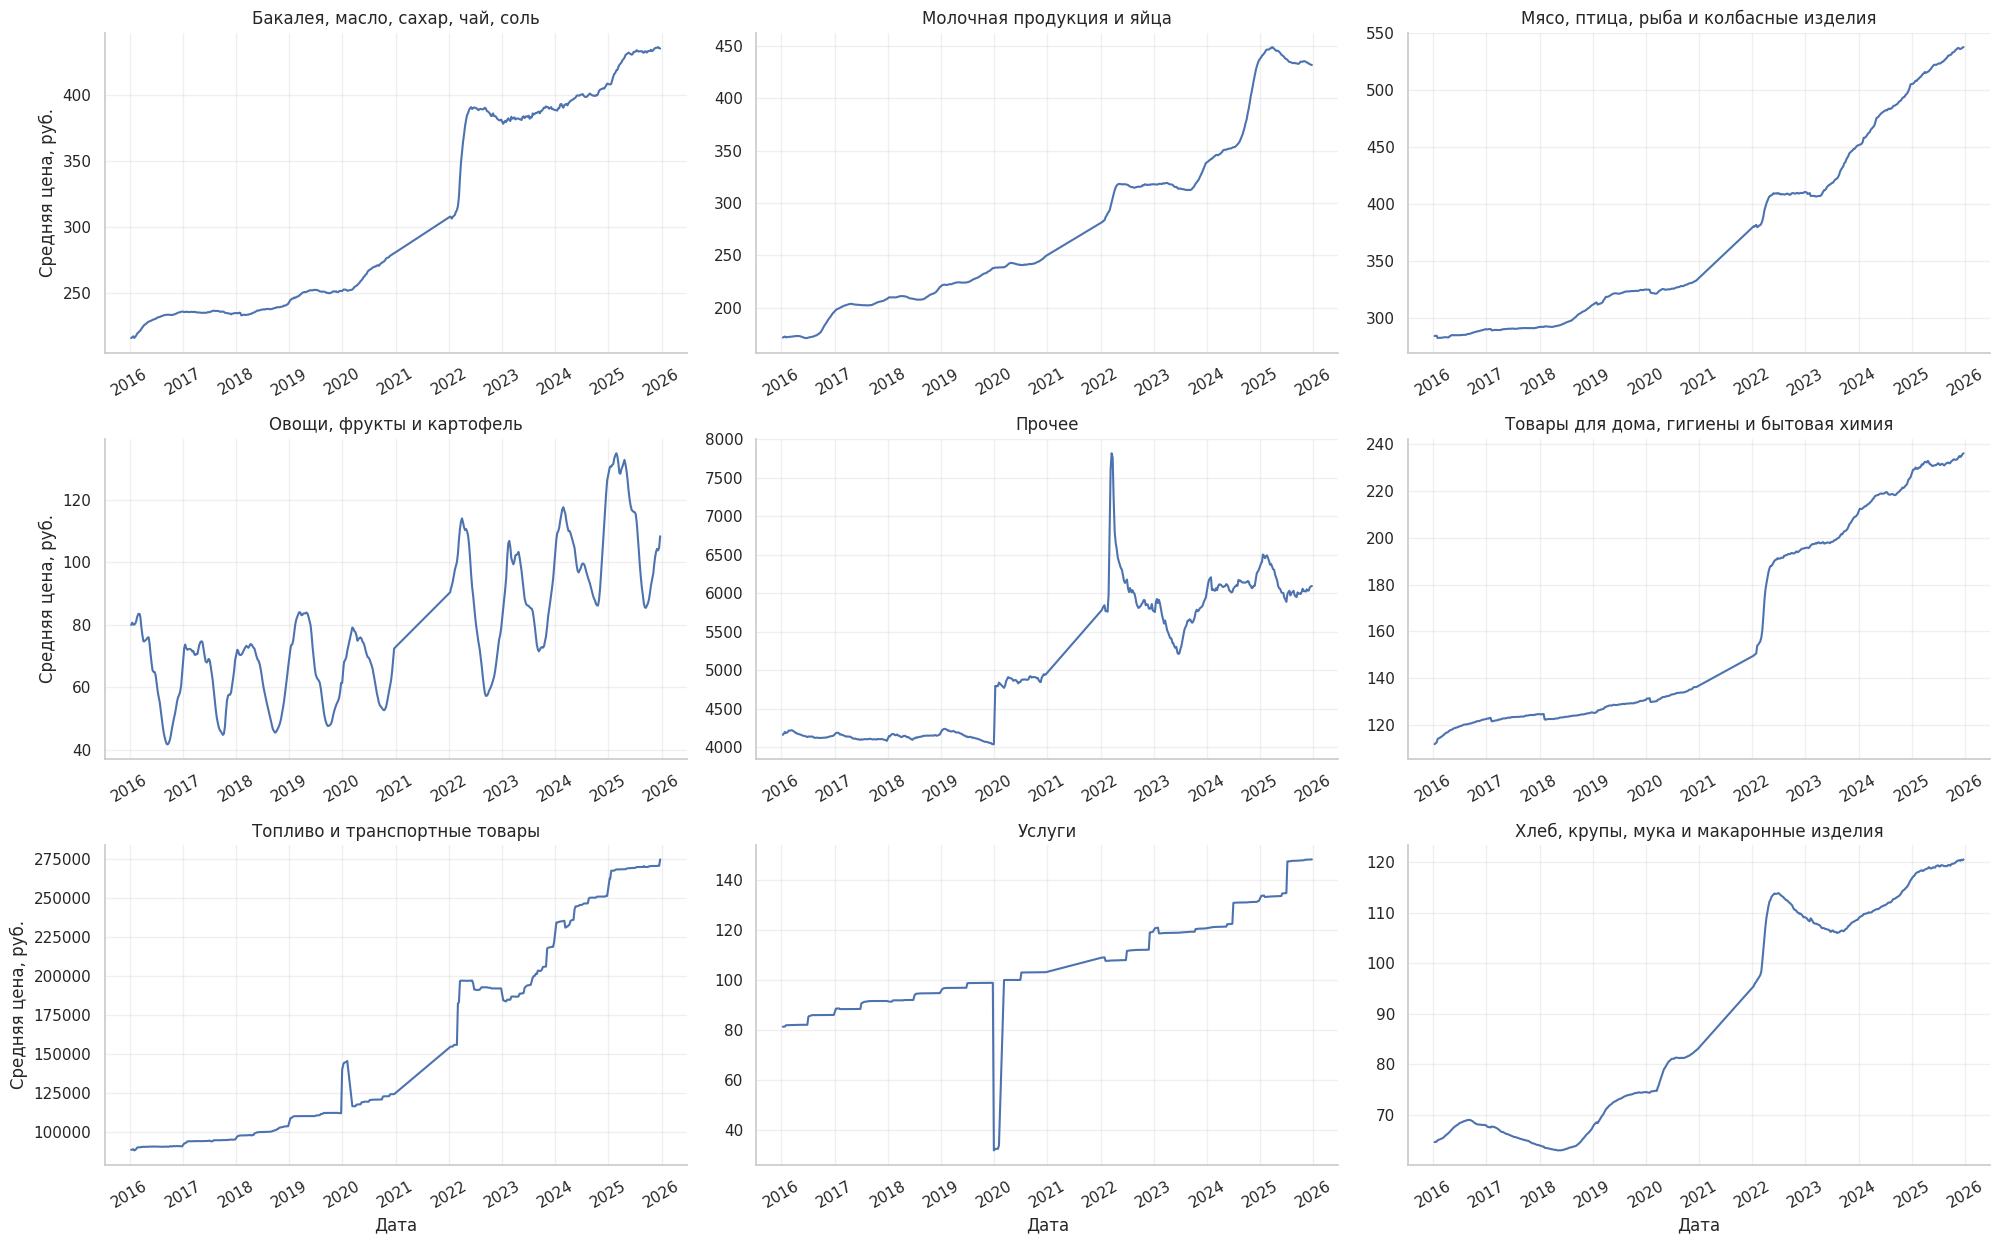

In [58]:
category_mean_ts = (
    prices_plot
    .groupby(["date", "product_group_name"], as_index=False)
    .agg(mean_price=("price", "mean"))
    .sort_values(["product_group_name", "date"])
)

g = sns.FacetGrid(
    category_mean_ts,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="date",
    y="mean_price"
)

g.set_axis_labels("Дата", "Средняя цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

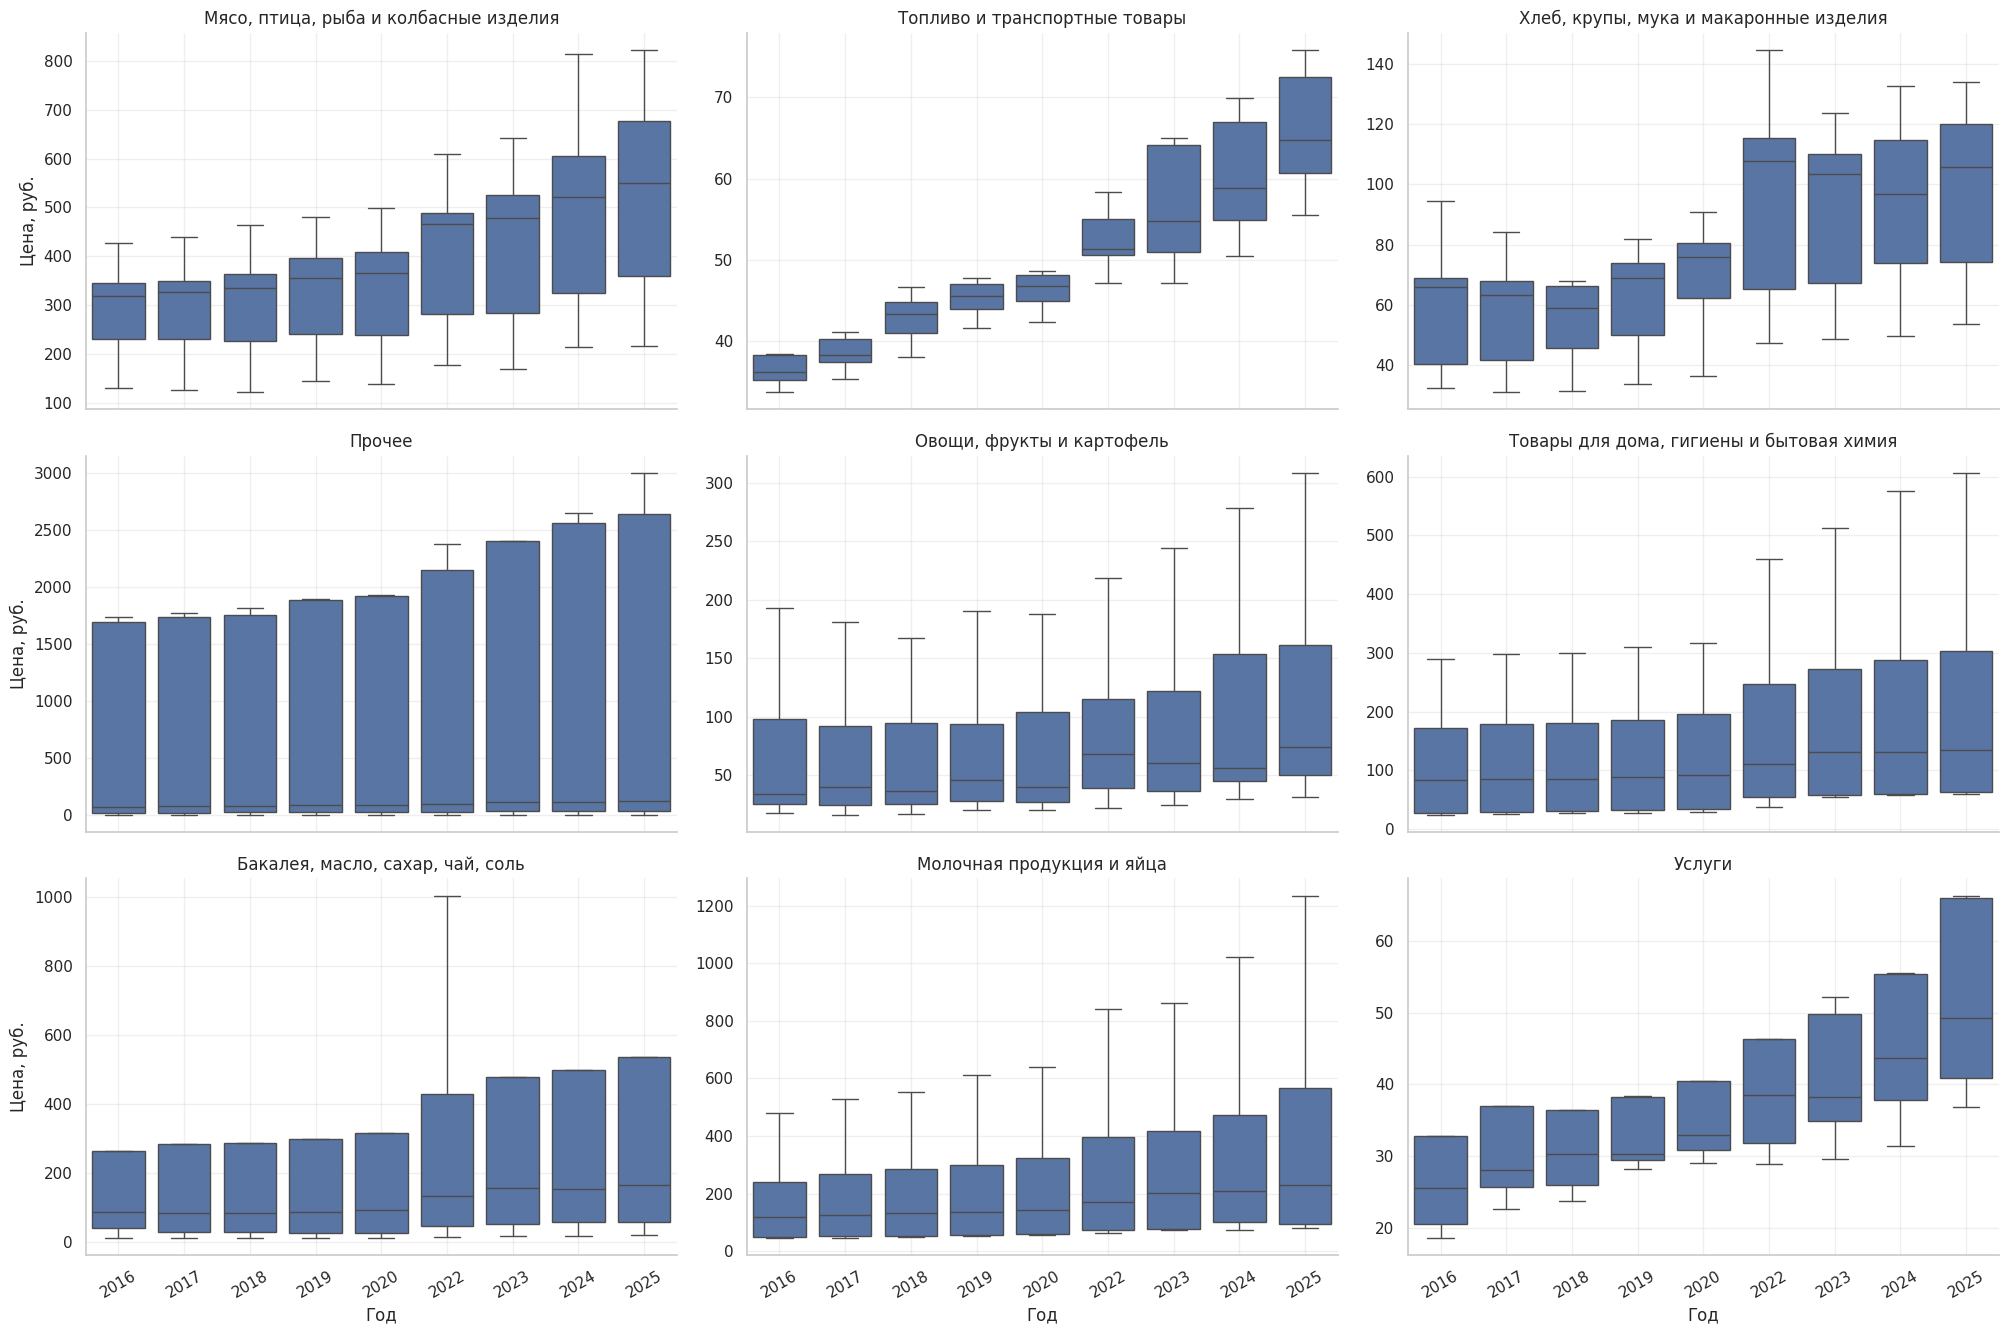

In [59]:
g = sns.FacetGrid(
    prices_plot,
    col="product_group_name",
    col_wrap=3,
    height=4.5,
    aspect=1.5,
    sharey=False
)

g.map_dataframe(
    sns.boxplot,
    x="year",
    y="price",
    order=sorted(prices_plot["year"].unique()),
    showfliers=False
)

g.set_axis_labels("Год", "Цена, руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", rotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

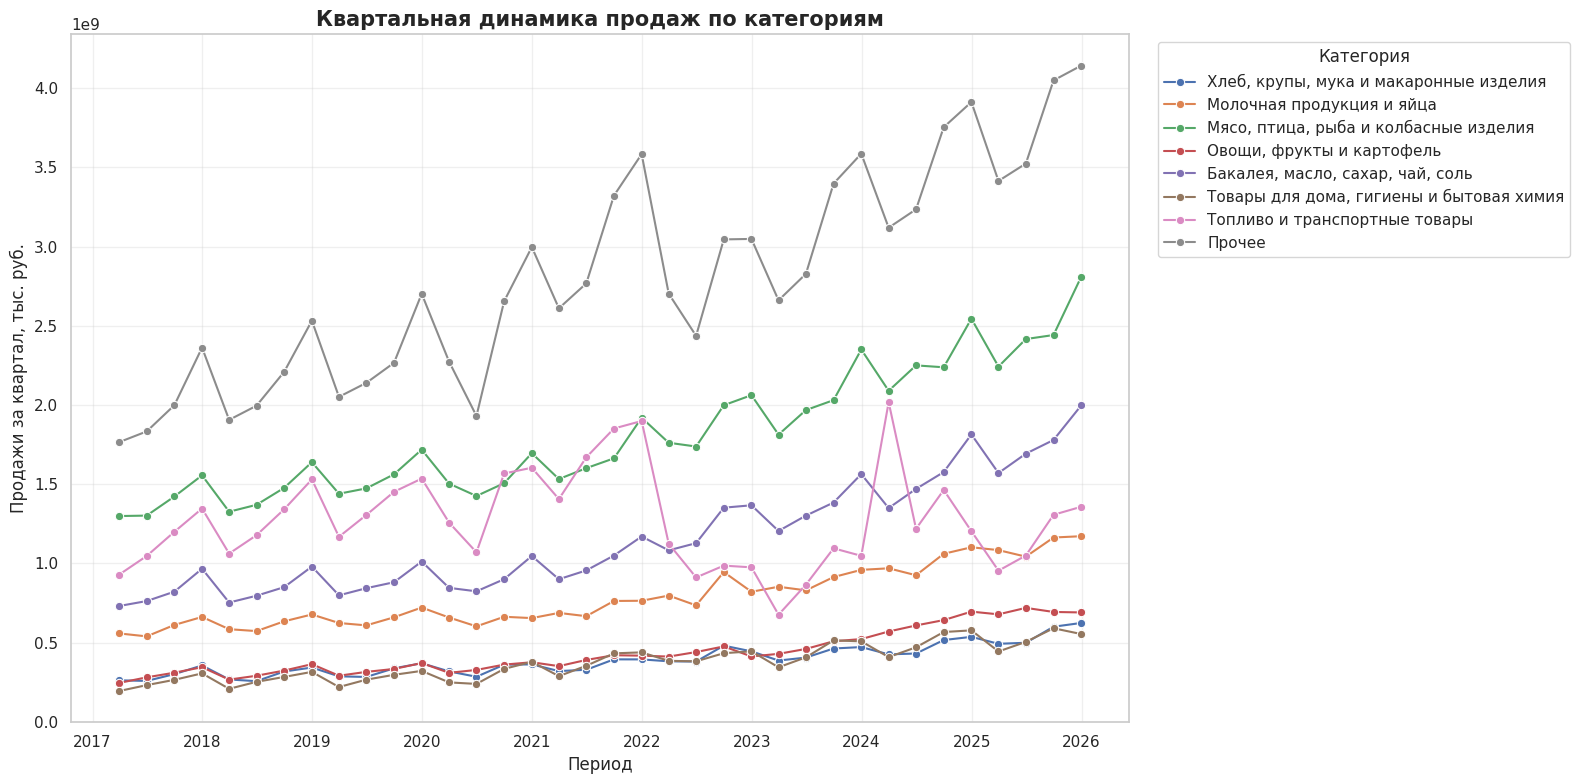

In [60]:
plt.figure(figsize=(16, 8))

sns.lineplot(
    data=sales_group_long,
    x="period_end",
    y="sales_quarter_thousand_rub",
    hue="product_group_name",
    marker="o"
)

plt.title("Квартальная динамика продаж по категориям", fontsize=15, fontweight="bold")
plt.xlabel("Период")
plt.ylabel("Продажи за квартал, тыс. руб.")
plt.legend(title="Категория", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

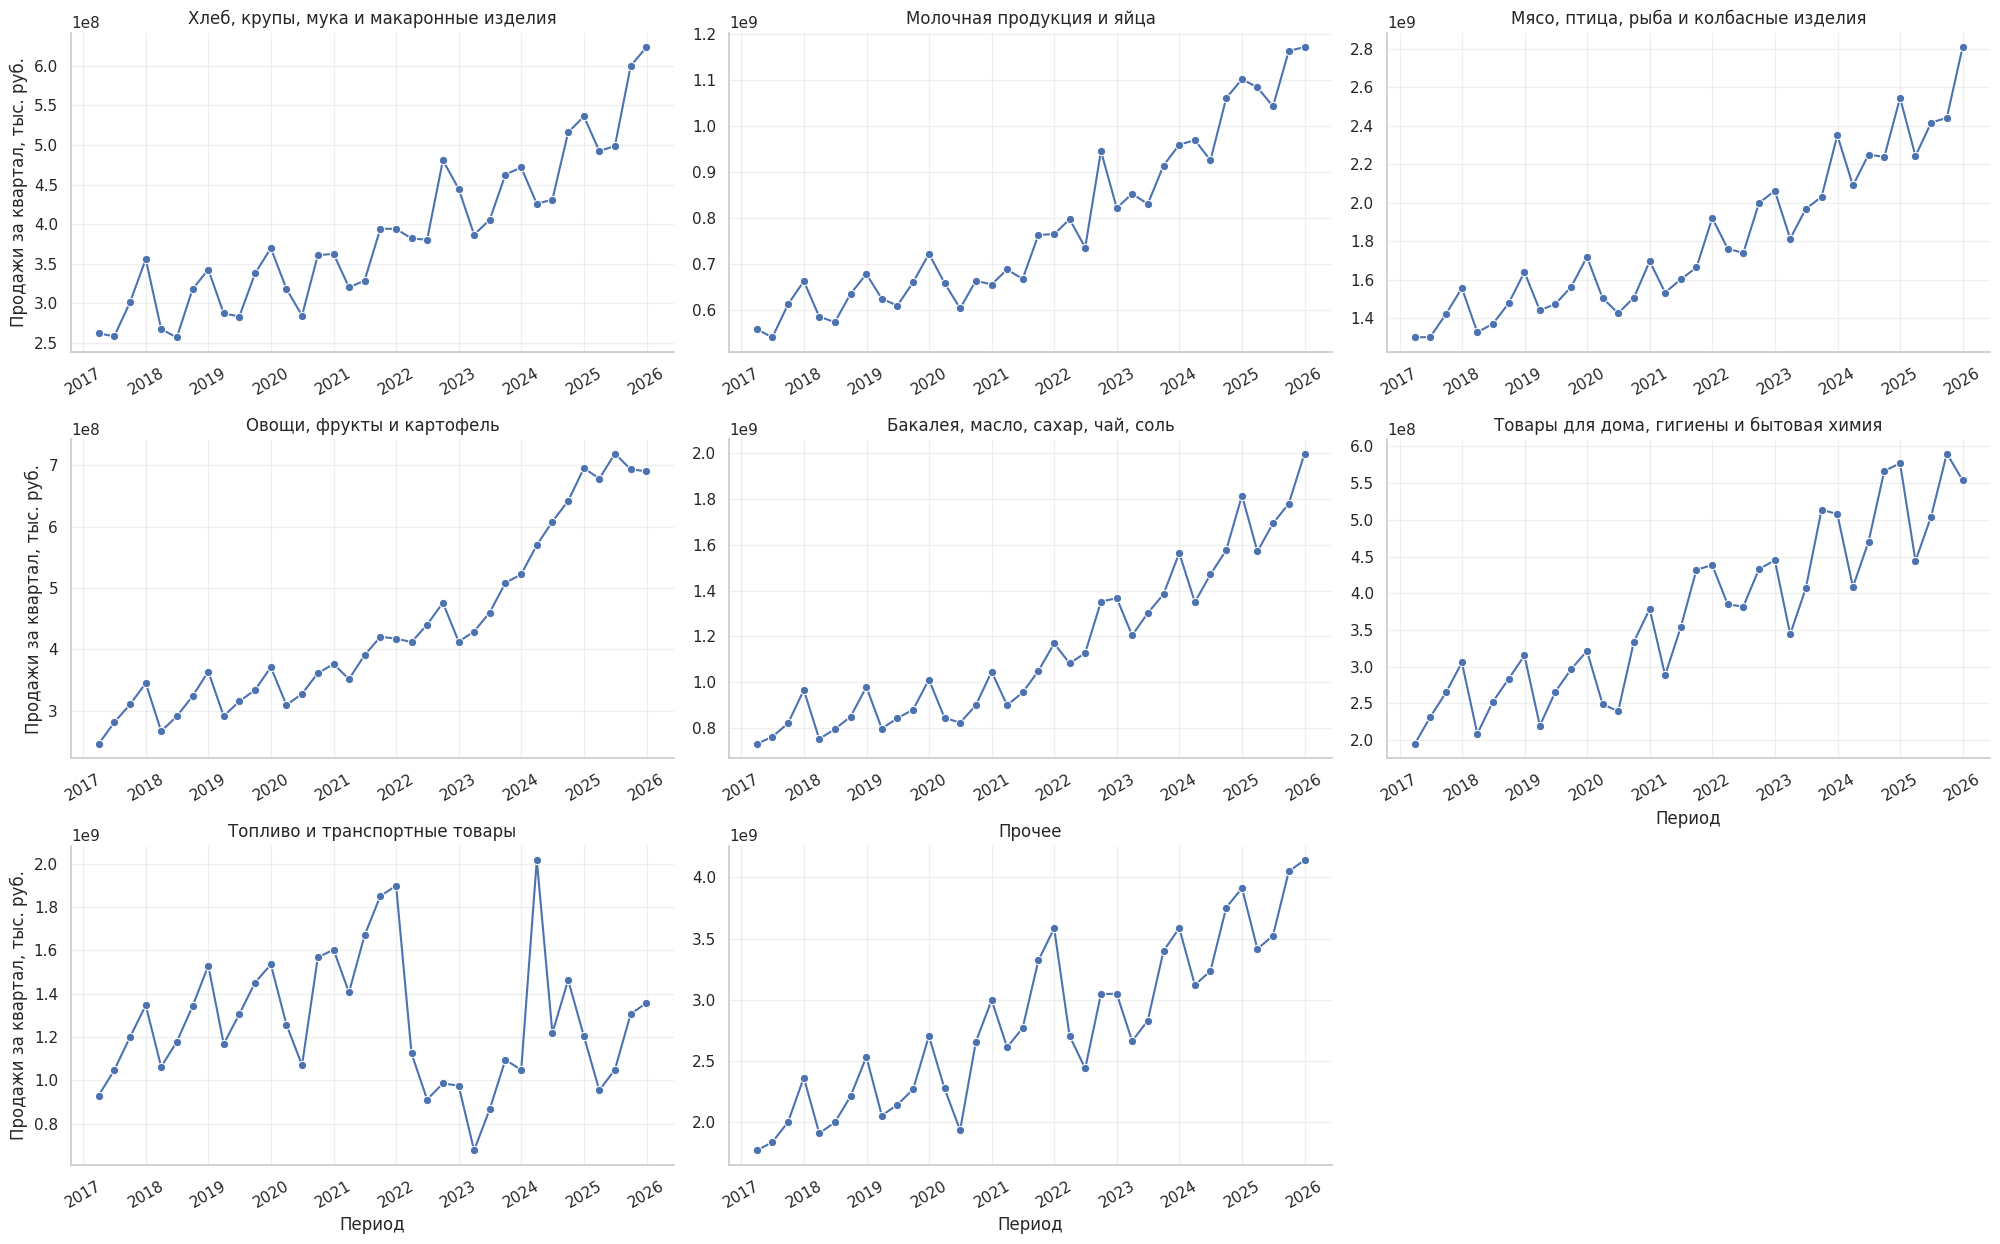

In [61]:
g = sns.FacetGrid(
    sales_group_long,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="sales_quarter_thousand_rub",
    marker="o"
)

g.set_axis_labels("Период", "Продажи за квартал, тыс. руб.")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

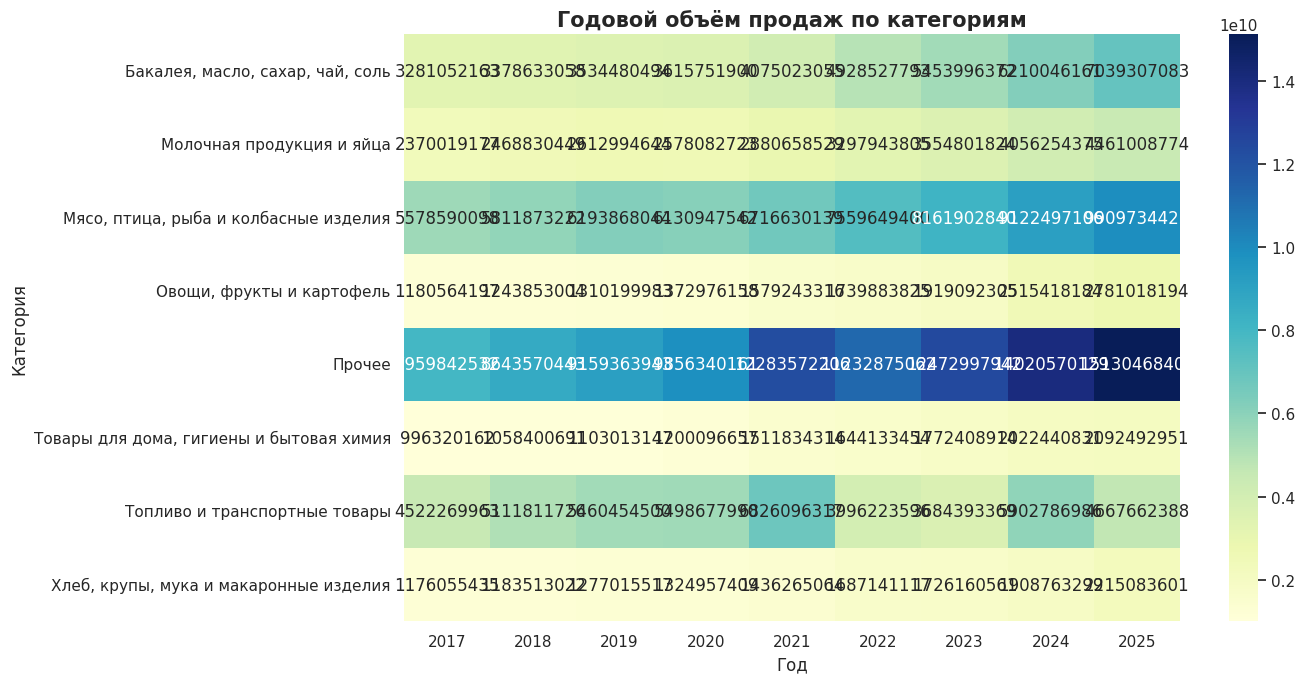

In [65]:
sales_year_category = (
    sales_group_long
    .groupby(["year", "product_group_name"], as_index=False)
    .agg(total_sales=("sales_quarter_thousand_rub", "sum"))
)

sales_heatmap = (
    sales_year_category
    .pivot_table(
        index="product_group_name",
        columns="year",
        values="total_sales",
        aggfunc="sum"
    )
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    sales_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Годовой объём продаж по категориям", fontsize=15, fontweight="bold")
plt.xlabel("Год")
plt.ylabel("Категория")

plt.tight_layout()
plt.show()

In [66]:
import pandas as pd
from pathlib import Path

ROSTAT_DIR = Path("/content/drive/MyDrive/rostat")

SALES_FILE = ROSTAT_DIR / "[2017-2025]_sales_dynamics.xls"
ROZN_FILE = ROSTAT_DIR / "[2017-2025]_rozn_dynamics.xls"

def check_fedstat_file_coverage(file_path):
    raw = pd.read_excel(
        file_path,
        sheet_name="Данные",
        header=None
    )
    
    current_year = None
    columns_meta = []
    
    for col_idx in range(2, raw.shape[1]):
        year_value = raw.iloc[2, col_idx]
        period_value = raw.iloc[3, col_idx]
        
        if pd.notna(year_value):
            try:
                current_year = int(float(year_value))
            except Exception:
                pass
        
        columns_meta.append({
            "col_idx": col_idx,
            "year": current_year,
            "period": period_value
        })
    
    columns_meta = pd.DataFrame(columns_meta)
    
    data = raw.iloc[4:].copy()
    data = data[data[0] == "Российская Федерация"]
    
    coverage = []
    
    for _, row in columns_meta.iterrows():
        col_idx = row["col_idx"]
        
        coverage.append({
            "year": row["year"],
            "period": row["period"],
            "non_empty_values": data[col_idx].notna().sum()
        })
    
    coverage = pd.DataFrame(coverage)
    
    return coverage

sales_coverage = check_fedstat_file_coverage(SALES_FILE)
rozn_coverage = check_fedstat_file_coverage(ROZN_FILE)

print("Покрытие sales_dynamics:")
display(sales_coverage)

print("Сводка sales_dynamics по годам:")
display(
    sales_coverage
    .groupby("year", as_index=False)
    .agg(non_empty_values=("non_empty_values", "sum"))
)

print("Покрытие rozn_dynamics:")
display(rozn_coverage)

print("Сводка rozn_dynamics по годам:")
display(
    rozn_coverage
    .groupby("year", as_index=False)
    .agg(non_empty_values=("non_empty_values", "sum"))
)

Покрытие sales_dynamics:


,year,period,non_empty_values
0,2017,январь-март,77
1,2017,январь-июнь,77
2,2017,январь-сентябрь,77
3,2017,январь-декабрь,77
4,2018,январь-март,77
5,2018,январь-июнь,77
6,2018,январь-сентябрь,77
7,2018,январь-декабрь,77
8,2019,январь-март,76
9,2019,январь-июнь,76


Сводка sales_dynamics по годам:


,year,non_empty_values
0,2017,308
1,2018,308
2,2019,304
3,2020,304
4,2021,304
5,2022,289
6,2023,0
7,2024,0
8,2025,0


Покрытие rozn_dynamics:


,year,period,non_empty_values
0,2017,январь-март,76
1,2017,январь-июнь,76
2,2017,январь-сентябрь,76
3,2017,январь-декабрь,76
4,2018,январь-март,76
5,2018,январь-июнь,76
6,2018,январь-сентябрь,76
7,2018,январь-декабрь,76
8,2018,значение показателя за год,76
9,2019,январь-март,75


Сводка rozn_dynamics по годам:


,year,non_empty_values
0,2017,304
1,2018,380
2,2019,375
3,2020,375
4,2021,375
5,2022,366
6,2023,0
7,2024,0
8,2025,0


In [67]:
display(
    sales_raw
    .groupby(["year", "region_original"], as_index=False)
    .agg(rows=("sales_cumulative_thousand_rub", "size"))
    .sort_values(["year", "region_original"])
)

,year,region_original,rows
0,2017,Российская Федерация,304
1,2018,Российская Федерация,304
2,2019,Российская Федерация,300
3,2020,Российская Федерация,300
4,2021,Российская Федерация,300
5,2022,Российская Федерация,289
6,2023,Российская Федерация без учета новых субъектов...,276
7,2024,Российская Федерация без учета новых субъектов...,293
8,2025,Российская Федерация без учета новых субъектов...,272


In [70]:
price_quarter_category = (
    prices_plot
    .groupby(["year", "quarter", "product_group_code", "product_group_name"], as_index=False)
    .agg(mean_price=("price", "mean"))
)

quarter_month_map = {1: 3, 2: 6, 3: 9, 4: 12}

price_quarter_category["period_end"] = price_quarter_category.apply(
    lambda row: pd.Timestamp(
        year=int(row["year"]),
        month=quarter_month_map[int(row["quarter"])],
        day=1
    ) + pd.offsets.MonthEnd(0),
    axis=1
)

price_quarter_category = price_quarter_category[
    ["period_end", "year", "quarter", "product_group_code", "product_group_name", "mean_price"]
]

In [71]:
price_sales_merged = price_quarter_category.merge(
    sales_group_long[
        [
            "period_end",
            "year",
            "quarter",
            "product_group_code",
            "product_group_name",
            "sales_quarter_thousand_rub"
        ]
    ],
    on=["period_end", "year", "quarter", "product_group_code", "product_group_name"],
    how="inner"
)

price_sales_merged = price_sales_merged.sort_values(
    ["product_group_code", "period_end"]
).reset_index(drop=True)

In [72]:
price_sales_merged["price_index"] = (
    price_sales_merged["mean_price"] /
    price_sales_merged.groupby("product_group_code")["mean_price"].transform("first")
) * 100

price_sales_merged["sales_index"] = (
    price_sales_merged["sales_quarter_thousand_rub"] /
    price_sales_merged.groupby("product_group_code")["sales_quarter_thousand_rub"].transform("first")
) * 100

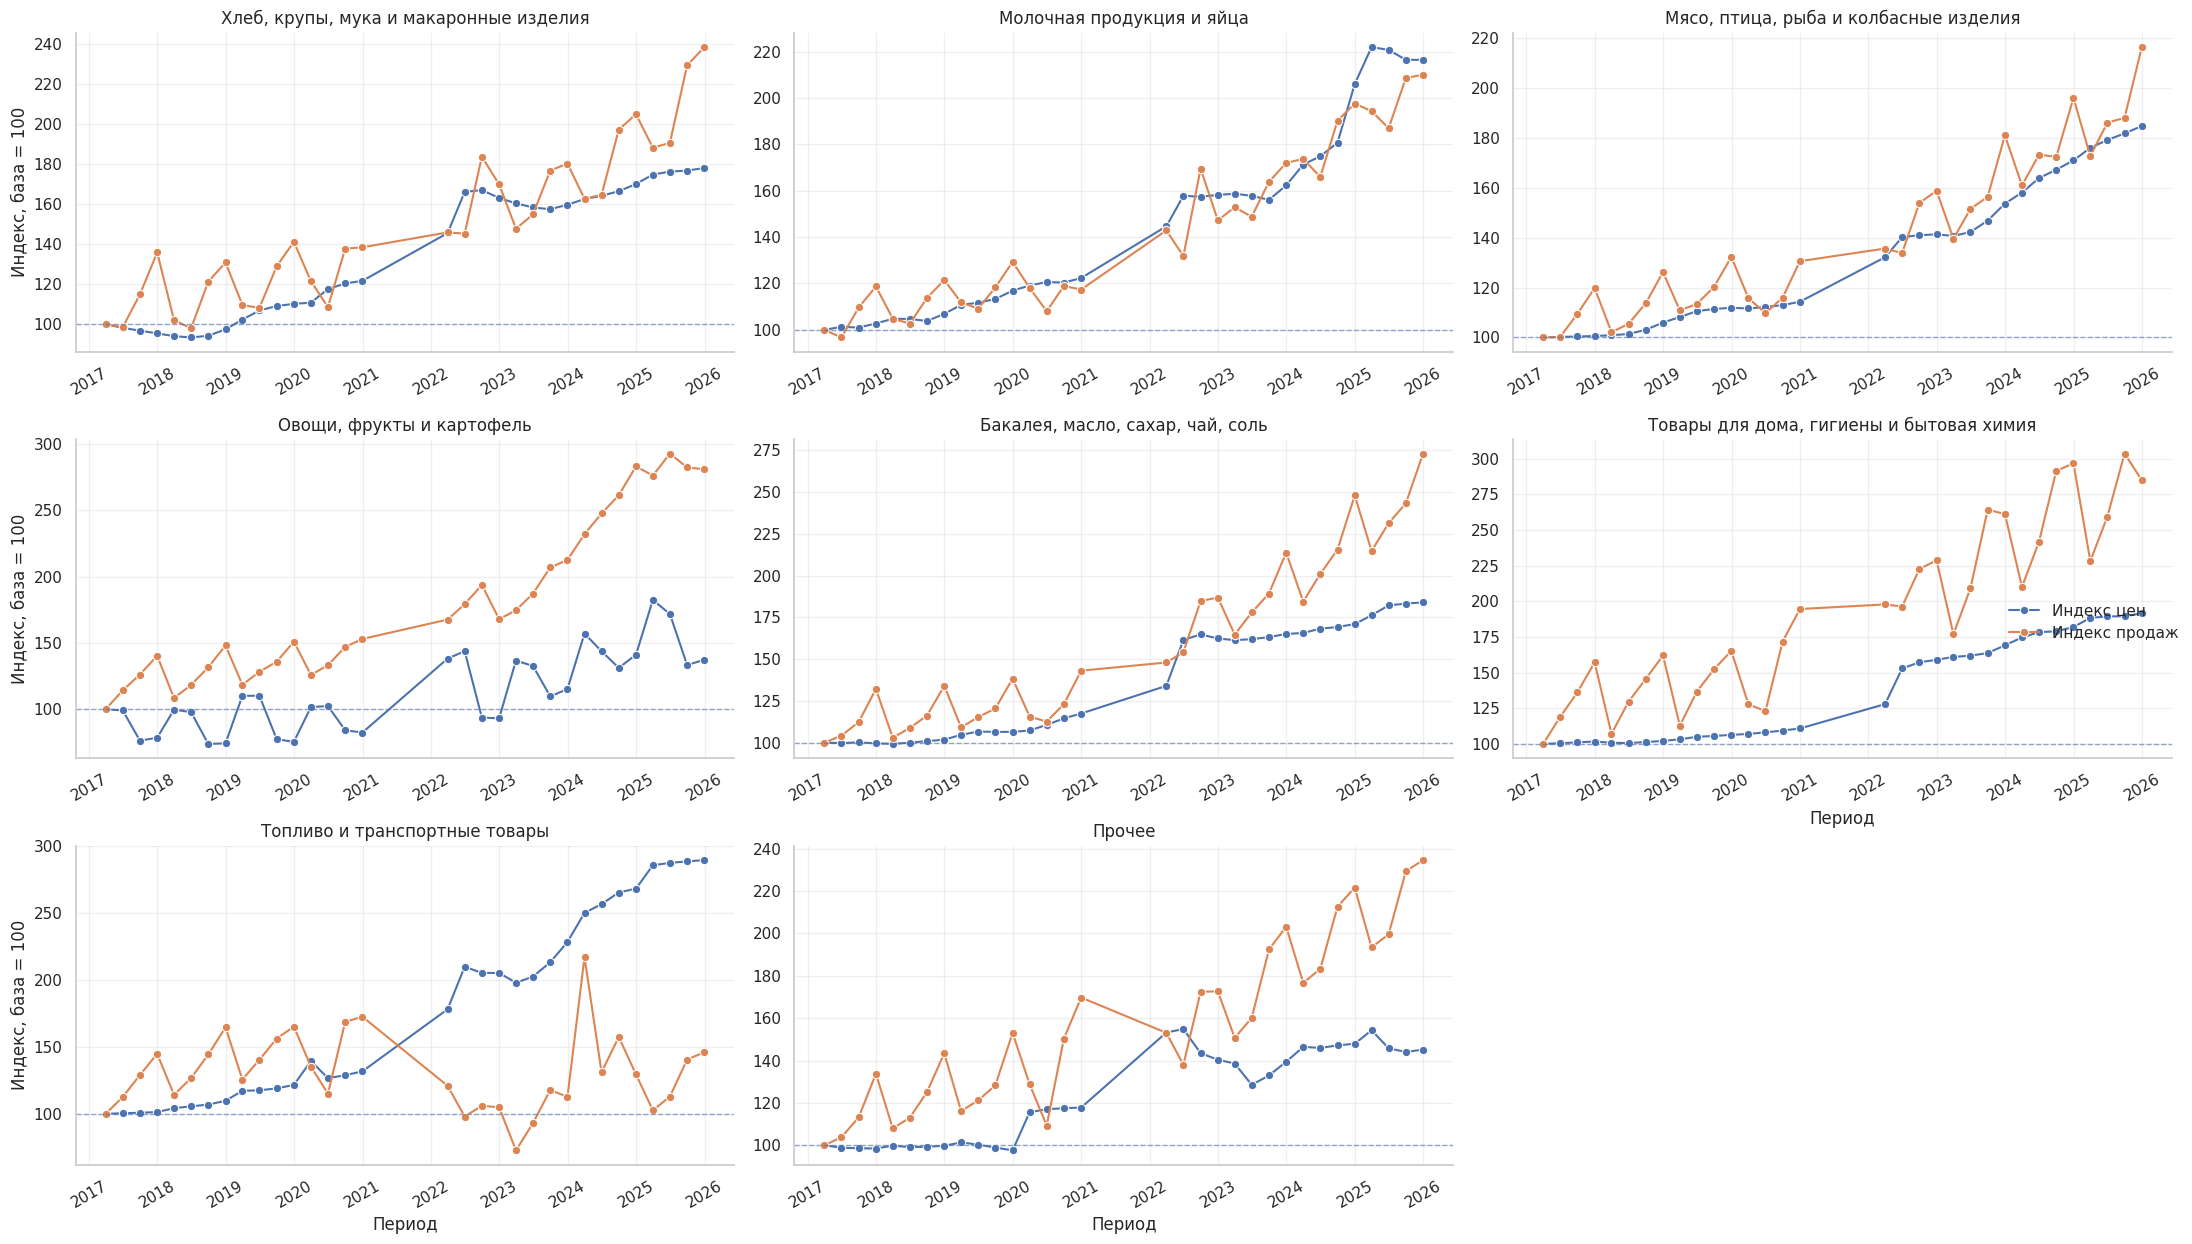

In [73]:
plot_df = pd.concat(
    [
        price_sales_merged[
            ["period_end", "product_group_name", "price_index"]
        ].rename(columns={"price_index": "value"}).assign(metric="Индекс цен"),
        price_sales_merged[
            ["period_end", "product_group_name", "sales_index"]
        ].rename(columns={"sales_index": "value"}).assign(metric="Индекс продаж")
    ],
    ignore_index=True
)

g = sns.FacetGrid(
    plot_df,
    col="product_group_name",
    col_wrap=3,
    height=4.2,
    aspect=1.6,
    hue="metric",
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="period_end",
    y="value",
    marker="o"
)

g.add_legend(title="")
g.set_axis_labels("Период", "Индекс, база = 100")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.axhline(100, linestyle="--", linewidth=1, alpha=0.6)
    ax.tick_params(axis="x", labelrotation=30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()